# 🛠️ Preprocesamiento de Imágenes
## Preparación de datos para modelos de ML

# Celda 1: Importar librerías

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Celda 2: Configuración

In [2]:
class Config:
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    TEST_SIZE = 0.2
    VAL_SIZE = 0.1
    RANDOM_STATE = 42
    
config = Config()

# Celda 3: Definir Dataset personalizado

In [3]:
class DogBreedDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, img_size=(224, 224)):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.img_size = img_size
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.img_size)
        
        if self.transform:
            image = self.transform(image=image)['image']
            
        return image, label

# Celda 4: Clase Preprocesador

In [4]:
class DataPreprocessor:
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.images_path = self.dataset_path / "images" / "Images"
        self.label_encoder = LabelEncoder()
        self.num_classes = None
        # Ruta al directorio raíz del proyecto
        self.project_root = Path(__file__).resolve().parent.parent.parent if '__file__' in globals() else Path.cwd().parent.parent
        
    def load_and_split_data(self, test_size=0.2, val_size=0.1, random_state=42):
        print("🔄 Cargando y dividiendo datos...")
        
        image_paths = []
        breed_names = []
        
        for breed_folder in self.images_path.iterdir():
            if breed_folder.is_dir():
                breed_name = breed_folder.name.split('-')[-1]
                for img_path in breed_folder.glob("*.jpg"):
                    image_paths.append(img_path)
                    breed_names.append(breed_name)
        
        labels_encoded = self.label_encoder.fit_transform(breed_names)
        self.num_classes = len(self.label_encoder.classes_)
        
        print(f"✅ Imágenes cargadas: {len(image_paths)}")
        print(f"✅ Razas únicas: {self.num_classes}")
        
        train_paths, temp_paths, train_labels, temp_labels = train_test_split(
            image_paths, labels_encoded, 
            test_size=test_size + val_size,
            stratify=labels_encoded,
            random_state=random_state
        )
        
        val_ratio = val_size / (test_size + val_size)
        val_paths, test_paths, val_labels, test_labels = train_test_split(
            temp_paths, temp_labels,
            test_size=1 - val_ratio,
            stratify=temp_labels,
            random_state=random_state
        )
        
        print(f"📊 División completada:")
        print(f"   🎯 Train: {len(train_paths)} imágenes")
        print(f"   🔍 Validation: {len(val_paths)} imágenes")
        print(f"   📈 Test: {len(test_paths)} imágenes")
        
        self._save_label_encoder()
        
        return (train_paths, train_labels, val_paths, val_labels, test_paths, test_labels)
    
    def _save_label_encoder(self):
        # Ruta correcta: desde notebooks/ subir hasta la raíz del proyecto
        models_dir = Path('../../backend/ML/models').resolve()
        models_dir.mkdir(parents=True, exist_ok=True)
        
        encoder_path = models_dir / 'label_encoder.pkl'
        joblib.dump(self.label_encoder, encoder_path)
        print(f"💾 Label encoder guardado en: {encoder_path}")
    
    def get_transforms(self):
        train_transform = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
        
        val_transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
        
        return train_transform, val_transform
    
    def create_data_loaders(self, batch_size=32, num_workers=2):
        (train_paths, train_labels, 
         val_paths, val_labels, 
         test_paths, test_labels) = self.load_and_split_data()
        
        train_transform, val_transform = self.get_transforms()
        
        train_dataset = DogBreedDataset(train_paths, train_labels, transform=train_transform)
        val_dataset = DogBreedDataset(val_paths, val_labels, transform=val_transform)
        test_dataset = DogBreedDataset(test_paths, test_labels, transform=val_transform)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        
        print(f"📦 DataLoaders creados:")
        print(f"   🎯 Train batches: {len(train_loader)}")
        print(f"   🔍 Val batches: {len(val_loader)}")
        print(f"   📈 Test batches: {len(test_loader)}")
        
        return train_loader, val_loader, test_loader
    
    def visualize_transformations(self, image_path, num_samples=5):
        train_transform, val_transform = self.get_transforms()
        
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        fig, axes = plt.subplots(1, num_samples + 1, figsize=(20, 4))
        
        axes[0].imshow(image)
        axes[0].set_title('Original', fontweight='bold')
        axes[0].axis('off')
        
        for i in range(num_samples):
            transformed = train_transform(image=image)['image']
            img_display = transformed.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)
            
            axes[i+1].imshow(img_display)
            axes[i+1].set_title(f'Transformada {i+1}', fontweight='bold')
            axes[i+1].axis('off')
        
        plt.tight_layout()
        plt.show()


# Celda 5: Ejecutar preprocesamiento

In [5]:
import kagglehub
from pathlib import Path

print("📥 Obteniendo dataset...")
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
print(f"✅ Dataset en: {path}")

# Verificar estructura
dataset_path = Path(path)
if (dataset_path / "images" / "Images").exists():
    print("✅ Estructura de carpetas correcta")
else:
    print("❌ Problema con la estructura de carpetas")
    print(f"Contenido: {list(dataset_path.iterdir())}")

preprocessor = DataPreprocessor(path)
# num_workers=0 para evitar problemas de multiprocessing en Windows
train_loader, val_loader, test_loader = preprocessor.create_data_loaders(batch_size=16, num_workers=0)


📥 Obteniendo dataset...
✅ Dataset en: C:\Users\yeder\.cache\kagglehub\datasets\jessicali9530\stanford-dogs-dataset\versions\2
✅ Estructura de carpetas correcta
🔄 Cargando y dividiendo datos...
✅ Imágenes cargadas: 20580
✅ Razas únicas: 119
📊 División completada:
   🎯 Train: 14405 imágenes
   🔍 Validation: 2058 imágenes
   📈 Test: 4117 imágenes
💾 Label encoder guardado en: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\label_encoder.pkl
📦 DataLoaders creados:
   🎯 Train batches: 901
   🔍 Val batches: 129
   📈 Test batches: 258


e:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Celda 6: Visualizar batch de datos

👀 Visualizando un batch de entrenamiento...
📐 Shape del batch: torch.Size([16, 3, 224, 224])
🎯 Shape de labels: torch.Size([16])
📊 Rango de píxeles: [-2.118, 2.640]


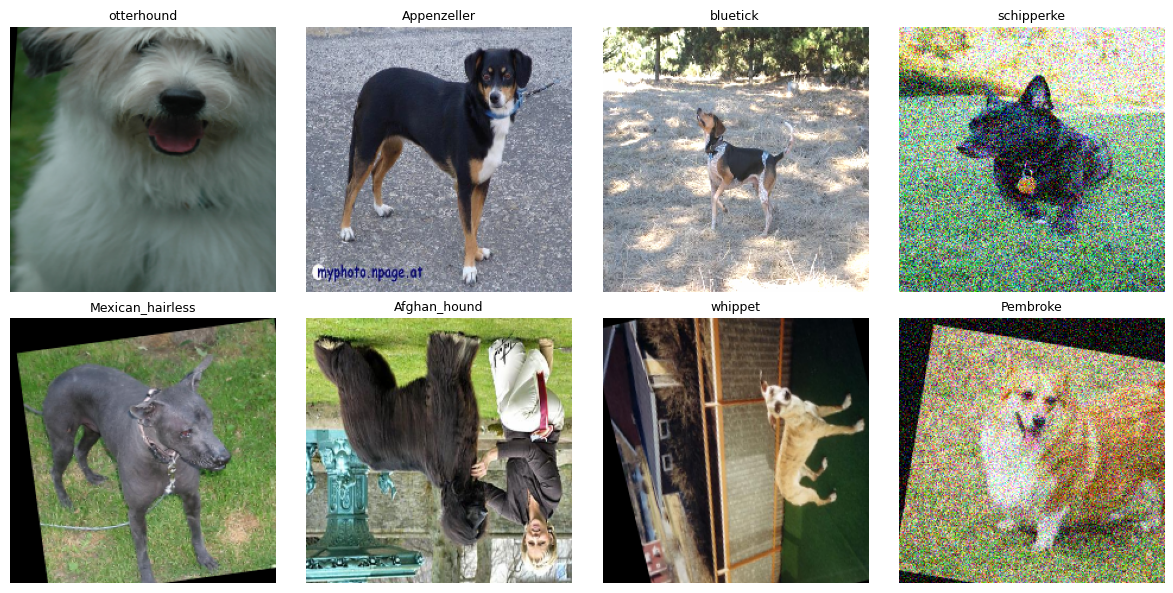

In [6]:
print("👀 Visualizando un batch de entrenamiento...")

for images, labels in train_loader:
    print(f"📐 Shape del batch: {images.shape}")
    print(f"🎯 Shape de labels: {labels.shape}")
    print(f"📊 Rango de píxeles: [{images.min():.3f}, {images.max():.3f}]")
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(8):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        axes[i//4, i%4].imshow(img)
        breed_name = preprocessor.label_encoder.inverse_transform([labels[i].numpy()])[0]
        axes[i//4, i%4].set_title(f'{breed_name}', fontsize=9)
        axes[i//4, i%4].axis('off')
    
    plt.tight_layout()
    plt.show()
    break

# Celda 7: Visualizar transformaciones

🎭 Visualizando transformaciones de data augmentation...


e:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


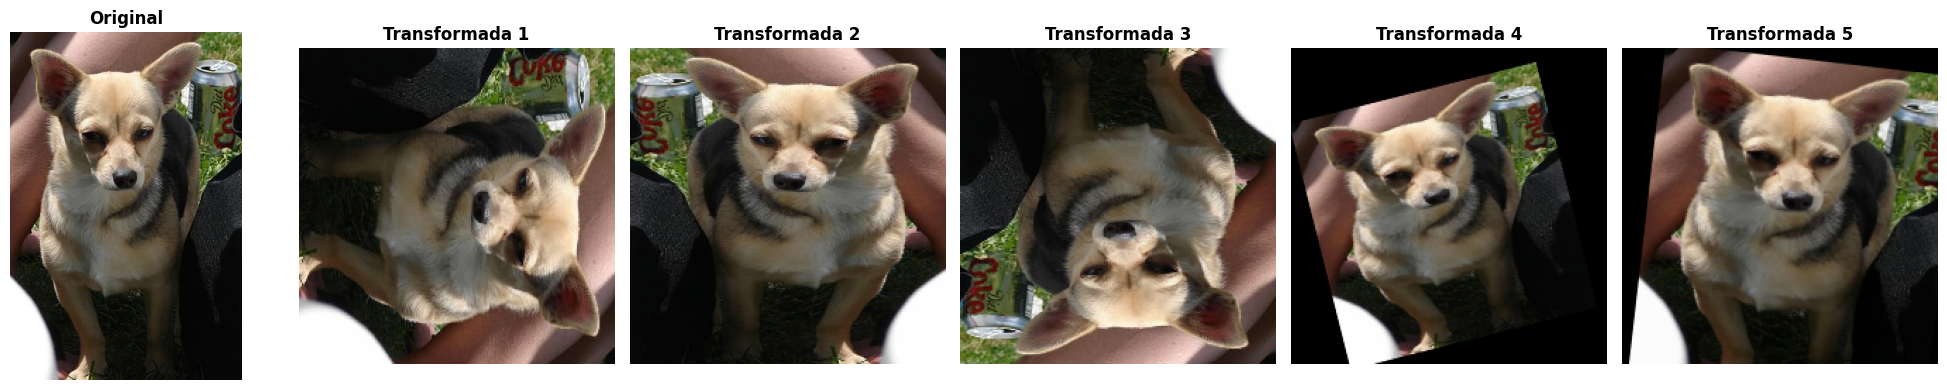

In [7]:
print("🎭 Visualizando transformaciones de data augmentation...")

sample_image_path = list(preprocessor.images_path.rglob("*.jpg"))[0]
preprocessor.visualize_transformations(sample_image_path, num_samples=5)

# Celda 8: Verificar label encoder

In [8]:
print("🔍 Verificando label encoder...")

# Ruta correcta al label encoder
encoder_path = Path('../../backend/ML/models/label_encoder.pkl').resolve()
label_encoder = joblib.load(encoder_path)
print(f"✅ Label encoder cargado desde: {encoder_path}")
print(f"✅ Número de clases: {len(label_encoder.classes_)}")
print(f"📋 Primeras 10 razas: {list(label_encoder.classes_)[:10]}")


🔍 Verificando label encoder...
✅ Label encoder cargado desde: E:\Documentos\Proyectos(clientes)\Dog_Breed_Identifier_ML\backend\ML\models\label_encoder.pkl
✅ Número de clases: 119
📋 Primeras 10 razas: [np.str_('Afghan_hound'), np.str_('African_hunting_dog'), np.str_('Airedale'), np.str_('American_Staffordshire_terrier'), np.str_('Appenzeller'), np.str_('Australian_terrier'), np.str_('Bedlington_terrier'), np.str_('Bernese_mountain_dog'), np.str_('Blenheim_spaniel'), np.str_('Border_collie')]
